#Sales and Customer Behaviour Insights - Green Cart Ltd.

This notebook analyses sales, product and customer data for Green Cart Ltd. to uncover insights into revenue performance, customer behaviour and delivery efficiency.

the analysis includes data cleaning, feature engineering, summary tables and visual exploration to support business decision-making.

In [2]:
#import of libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

##Data Loading

Three datasets are used in this analysis:
- **Sales Dataset:** transaction-order details
- **Product Dataset:** product categories, pricing and launch information
- **Customer Dataset:** customer
demographics and loyalty information

All dataset are loaded using pandas for further cleaning and analysis

In [3]:
sales_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/sales_data.csv')
product_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/product_info.csv')
customer_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/customer_info.csv')

In [4]:
#sales dataset
sales_df.head()

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region,discount_applied
0,O966977,C00397,P0022,3,39.25,06-07-2025,Delivered,PayPal,Central,0.00
1,O696648,C00236,P0023,5,18.92,06-07-2025,DELAYED,credit card,North,0.00
2,O202644,C00492,P0011,1,29.68,07-07-2025,delivered,Bank Transfer,North,0.15
3,O501803,C00031,P0003,1,32.76,08-07-2025,Cancelled,Credit Card,Central,0.20
4,O322242,C00495,P0016,1,47.62,08-07-2025,DELAYED,Credit Card,West,0.20


In [5]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          2999 non-null   object 
 1   customer_id       2998 non-null   object 
 2   product_id        2995 non-null   object 
 3   quantity          2997 non-null   object 
 4   unit_price        2999 non-null   float64
 5   order_date        2998 non-null   object 
 6   delivery_status   2997 non-null   object 
 7   payment_method    2997 non-null   object 
 8   region            3000 non-null   object 
 9   discount_applied  2483 non-null   float64
dtypes: float64(2), object(8)
memory usage: 234.5+ KB


In [6]:
#product dataset
product_df.head()

,product_id,product_name,category,launch_date,base_price,supplier_code
0,P0001,Storage Product 39,Storage,11-03-25,15.88,S339
1,P0002,Cleaning Product 82,Cleaning,18-08-24,34.23,S974
2,P0003,Cleaning Product 85,Cleaning,15-07-24,7.92,S745
3,P0004,Kitchen Product 82,Kitchen,19-04-25,9.13,S589
4,P0005,Personal Care Product 1,Personal Care,20-10-24,31.10,S559


In [7]:
product_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   product_id     30 non-null     object 
 1   product_name   30 non-null     object 
 2   category       30 non-null     object 
 3   launch_date    30 non-null     object 
 4   base_price     30 non-null     float64
 5   supplier_code  30 non-null     object 
dtypes: float64(1), object(5)
memory usage: 1.5+ KB


In [8]:
#customer dataset
customer_df.head()

,customer_id,email,signup_date,gender,region,loyalty_tier
0,C00001,shaneramirez@gmail.com,26-04-25,Male,Central,Silver
1,C00002,jpeterson@bernard.com,11-08-24,Female,Central,gold
2,C00003,howardmaurice@yahoo.com,15-05-25,male,Central,gold
3,C00004,yherrera@arnold.org,14-06-25,FEMALE,Central,GOLD
4,C00005,janetwilliams@gmail.com,02-05-25,Male,West,bronze


In [9]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   customer_id   497 non-null    object
 1   email         494 non-null    object
 2   signup_date   496 non-null    object
 3   gender        496 non-null    object
 4   region        497 non-null    object
 5   loyalty_tier  498 non-null    object
dtypes: object(6)
memory usage: 23.6+ KB


##Data Cleaning - Sales Dataset

The sales dataset was cleaned to ensure consistency and accuracy.
Key steps included:
- Standardising text fields such as delivery status, payment method and region
- converting order dates into datetime format
- handling missing discount values by replacing them with zero
- removing rows with missing critical transaction information
- removing duplicate order records to avoid double-counting revenue

In [10]:
#data cleaning - sales dataset
#standardise text value/column
sales_df['delivery_status'] = (sales_df['delivery_status']
                               .str.strip()
                               .str.title())

sales_df['payment_method'] = (sales_df['payment_method']
                               .str.strip()
                               .str.title())

sales_df['region'] = (sales_df['region']
                               .str.strip()
                               .str.title())

In [11]:
sales_df[['delivery_status', 'payment_method', 'region']].head(10)

,delivery_status,payment_method,region
0,Delivered,Paypal,Central
1,Delayed,Credit Card,North
2,Delivered,Bank Transfer,North
3,Cancelled,Credit Card,Central
4,Delayed,Credit Card,West
5,Delayed,Bank Transfer,North
6,Delivered,Paypal,Central
7,Delivered,Credit Card,East
8,Delivered,Paypal,Central
9,Delayed,Credit Card,South


In [12]:
#convert order_date to datetime
sales_df['order_date'] = pd.to_datetime(sales_df['order_date'], dayfirst=True, errors = 'coerce')
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          2999 non-null   object        
 1   customer_id       2998 non-null   object        
 2   product_id        2995 non-null   object        
 3   quantity          2997 non-null   object        
 4   unit_price        2999 non-null   float64       
 5   order_date        2998 non-null   datetime64[ns]
 6   delivery_status   2997 non-null   object        
 7   payment_method    2997 non-null   object        
 8   region            3000 non-null   object        
 9   discount_applied  2483 non-null   float64       
dtypes: datetime64[ns](1), float64(2), object(7)
memory usage: 234.5+ KB


In [13]:
#checking missing values
sales_df.isnull().sum()

,0
order_id,1
customer_id,2
product_id,5
quantity,3
unit_price,1
order_date,2
delivery_status,3
payment_method,3
region,0
discount_applied,517


In [14]:
#fill missing (NaN) discount values with 0.0
sales_df['discount_applied'] = sales_df['discount_applied'].fillna(0.0)

In [15]:
#dropping columns that have rows with missing values
sales_df = sales_df.dropna(
    subset=[
        'order_id',
        'customer_id',
        'product_id',
        'quantity',
        'unit_price',
        'order_date',
        'delivery_status',
        'payment_method',
    ]
)

In [16]:
sales_df.isnull().sum()

,0
order_id,0
customer_id,0
product_id,0
quantity,0
unit_price,0
order_date,0
delivery_status,0
payment_method,0
region,0
discount_applied,0


In [17]:
#checking for duplicates on column that is for transactional purpose
sales_df.duplicated(subset=['order_id']).sum()

np.int64(2)

In [18]:
#removing duplicates
sales_df = sales_df.drop_duplicates(subset=['order_id'])

In [19]:
#validate and checking numeric values/column
sales_df[['quantity', 'unit_price', 'discount_applied']].describe()

,unit_price,discount_applied
count,2978.000000,2978.000000
mean,28.933959,0.082858
std,12.080568,0.074046
min,8.000000,0.000000
25%,18.812500,0.000000
50%,28.610000,0.050000
75%,39.625000,0.150000
max,49.990000,0.200000


##Data Cleaning - Product Dataset

The product dataset was reviwed and cleaned by:
- Standardising product names, categories and supplier codes
- converting launch dates into datetime format
- confirming there were no missing values or duplicate product records
- validating pricing data to ensure no negative or invalid values were present

In [20]:
#data cleaning - product dataset
#standardise text value/column
product_df['product_name'] = (product_df['product_name']
                              .str.strip()
                              .str.title())

product_df['category'] = (product_df['category']
                          .str.strip()
                          .str.title())

product_df['supplier_code'] = (product_df['supplier_code']
                               .str.strip()
                               .str.upper()) #uppercase ID

product_df[['product_name', 'category', 'supplier_code']].head()

,product_name,category,supplier_code
0,Storage Product 39,Storage,S339
1,Cleaning Product 82,Cleaning,S974
2,Cleaning Product 85,Cleaning,S745
3,Kitchen Product 82,Kitchen,S589
4,Personal Care Product 1,Personal Care,S559


In [21]:
#converting launch_date to datetime
product_df['launch_date'] = pd.to_datetime(product_df['launch_date'], dayfirst=True, errors = 'coerce')
product_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   product_id     30 non-null     object        
 1   product_name   30 non-null     object        
 2   category       30 non-null     object        
 3   launch_date    30 non-null     datetime64[ns]
 4   base_price     30 non-null     float64       
 5   supplier_code  30 non-null     object        
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 1.5+ KB


/tmp/ipython-input-1833762548.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  product_df['launch_date'] = pd.to_datetime(product_df['launch_date'], dayfirst=True, errors = 'coerce')


In [22]:
#checking for missing values
product_df.isnull().sum()

,0
product_id,0
product_name,0
category,0
launch_date,0
base_price,0
supplier_code,0


In [23]:
#checking duplicates
product_df.duplicated(subset=['product_id']).sum()

np.int64(0)

In [24]:
#validating numeric values/column for negative values
product_df['base_price'].describe()

,base_price
count,30.000000
mean,22.844333
std,10.269165
min,6.080000
25%,14.812500
50%,23.230000
75%,31.745000
max,39.210000


##Data Cleaning - Customer Dataset

The customer dataset required additional cleaning due to inconsistent formatting and missing values.
Actions taken included:
- Standardising gender, region and loyalty tier labels
- converting signup dates into datetime format
- filling missing categorical values with 'Unknwon'
- removing records with missing essential customer identifiers
- confirming no duplicate customer records remained

In [25]:
#data cleaning - customer dataset
#standardise text columns
customer_df['gender'] = (customer_df['gender']
                         .str.strip()
                         .str.title())

customer_df['region'] = (customer_df['region']
                         .str.strip()
                         .str.title())

customer_df['loyalty_tier'] = (customer_df['loyalty_tier']
                             .str.strip()
                             .str.title())

customer_df[['gender', 'region', 'loyalty_tier']].head()

,gender,region,loyalty_tier
0,Male,Central,Silver
1,Female,Central,Gold
2,Male,Central,Gold
3,Female,Central,Gold
4,Male,West,Bronze


In [26]:
#convert signup_date to datetime
customer_df['signup_date'] = pd.to_datetime(customer_df['signup_date'], dayfirst=True, errors='coerce')
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   customer_id   497 non-null    object        
 1   email         494 non-null    object        
 2   signup_date   496 non-null    datetime64[ns]
 3   gender        496 non-null    object        
 4   region        497 non-null    object        
 5   loyalty_tier  498 non-null    object        
dtypes: datetime64[ns](1), object(5)
memory usage: 23.6+ KB


/tmp/ipython-input-1556702716.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  customer_df['signup_date'] = pd.to_datetime(customer_df['signup_date'], dayfirst=True, errors='coerce')


In [27]:
#check missing values
customer_df.isnull().sum()

,0
customer_id,3
email,6
signup_date,4
gender,4
region,3
loyalty_tier,2


In [28]:
#filling categorical values
customer_df['gender'] = customer_df['gender'].fillna('Unknown')
customer_df['loyalty_tier'] = customer_df['loyalty_tier'].fillna('Unknown')

In [29]:
#dropping rows that have missing information about customer
customer_df = customer_df.dropna(
    subset=[
        'customer_id',
        'email',
        'signup_date',
        'region'])

In [30]:
#checking for missing values
customer_df.isnull().sum()

,0
customer_id,0
email,0
signup_date,0
gender,0
region,0
loyalty_tier,0


In [31]:
#checking duplicates
customer_df.duplicated(subset=['customer_id']).sum()

np.int64(0)

## Data Merging

The cleaned datasets were merged into a single analytical dataset:
- Sales dataset was merged with product dataset using product_id
- The resulting dataset was merged with customer dataset using customer_id
- A left join was used to preserve all valid sales transactions

This merged dataset forms the basis for feature engineering and analysis.

Correcting data inconsistencies and numeric conversion

In [32]:
#merging data
merged_df = pd.merge(sales_df, product_df, on='product_id', how='left')
merged_df.info()
merged_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2978 entries, 0 to 2977
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          2978 non-null   object        
 1   customer_id       2978 non-null   object        
 2   product_id        2978 non-null   object        
 3   quantity          2978 non-null   object        
 4   unit_price        2978 non-null   float64       
 5   order_date        2978 non-null   datetime64[ns]
 6   delivery_status   2978 non-null   object        
 7   payment_method    2978 non-null   object        
 8   region            2978 non-null   object        
 9   discount_applied  2978 non-null   float64       
 10  product_name      2978 non-null   object        
 11  category          2978 non-null   object        
 12  launch_date       2978 non-null   datetime64[ns]
 13  base_price        2978 non-null   float64       
 14  supplier_code     2978 n

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region,discount_applied,product_name,category,launch_date,base_price,supplier_code
0,O966977,C00397,P0022,3,39.25,2025-07-06,Delivered,Paypal,Central,0.00,Cleaning Product 86,Cleaning,2024-10-04,19.77,S924
1,O696648,C00236,P0023,5,18.92,2025-07-06,Delayed,Credit Card,North,0.00,Outdoors Product 32,Outdoors,2025-01-18,36.04,S907
2,O202644,C00492,P0011,1,29.68,2025-07-07,Delivered,Bank Transfer,North,0.15,Kitchen Product 53,Kitchen,2025-03-25,11.08,S645
3,O501803,C00031,P0003,1,32.76,2025-07-08,Cancelled,Credit Card,Central,0.20,Cleaning Product 85,Cleaning,2024-07-15,7.92,S745
4,O322242,C00495,P0016,1,47.62,2025-07-08,Delayed,Credit Card,West,0.20,Cleaning Product 53,Cleaning,2025-02-20,26.71,S715


In [33]:
merged_df = pd.merge(merged_df, customer_df, on='customer_id', how='left')
merged_df.info()
merged_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2978 entries, 0 to 2977
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          2978 non-null   object        
 1   customer_id       2978 non-null   object        
 2   product_id        2978 non-null   object        
 3   quantity          2978 non-null   object        
 4   unit_price        2978 non-null   float64       
 5   order_date        2978 non-null   datetime64[ns]
 6   delivery_status   2978 non-null   object        
 7   payment_method    2978 non-null   object        
 8   region_x          2978 non-null   object        
 9   discount_applied  2978 non-null   float64       
 10  product_name      2978 non-null   object        
 11  category          2978 non-null   object        
 12  launch_date       2978 non-null   datetime64[ns]
 13  base_price        2978 non-null   float64       
 14  supplier_code     2978 n

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region_x,discount_applied,product_name,category,launch_date,base_price,supplier_code,email,signup_date,gender,region_y,loyalty_tier
0,O966977,C00397,P0022,3,39.25,2025-07-06,Delivered,Paypal,Central,0.00,Cleaning Product 86,Cleaning,2024-10-04,19.77,S924,jacquelinemartin@mills-logan.com,2024-09-08,Female,North,Silver
1,O696648,C00236,P0023,5,18.92,2025-07-06,Delayed,Credit Card,North,0.00,Outdoors Product 32,Outdoors,2025-01-18,36.04,S907,georgeweber@morgan.com,2024-08-06,Other,North,Gold
2,O202644,C00492,P0011,1,29.68,2025-07-07,Delivered,Bank Transfer,North,0.15,Kitchen Product 53,Kitchen,2025-03-25,11.08,S645,lcook@walters-smith.com,2024-09-25,Male,Central,Gold
3,O501803,C00031,P0003,1,32.76,2025-07-08,Cancelled,Credit Card,Central,0.20,Cleaning Product 85,Cleaning,2024-07-15,7.92,S745,smoore@gmail.com,2024-07-28,Femle,Central,Gold
4,O322242,C00495,P0016,1,47.62,2025-07-08,Delayed,Credit Card,West,0.20,Cleaning Product 53,Cleaning,2025-02-20,26.71,S715,mcclainkatherine@hotmail.com,2024-09-18,Male,Central,Gold


In [34]:
#data incosistency correction (issues identified during analysis)
delivery_mapping = {'Delrd': 'Delivered','Delyd': 'Delayed'}

merged_df['delivery_status'] = merged_df['delivery_status'].replace(delivery_mapping)
merged_df['delivery_status'] = merged_df['delivery_status'].str.title()

#fixing region typo discovered during visualisation
merged_df['region_x'] = merged_df['region_x'].replace({'Nrth': 'North'})

In [35]:
#numeric conversion
merged_df['quantity'] = pd.to_numeric(merged_df['quantity'], errors='coerce')
merged_df['unit_price'] = pd.to_numeric(merged_df['unit_price'], errors='coerce')
merged_df['discount_applied'] = pd.to_numeric(merged_df['discount_applied'], errors='coerce')

##Feature Engineering

Several new features were created to support analysis:
- **Revenue:** calculated using quantity, unit price, and discount applied
- **Order week:** ISO week extracted from order date
- **Price band:** categorised unit prices into low, medium, and high ranges
- **Days to order:** time between product launch and purchase
- **Email domain:** extracted from customer email addresses
- **Is late:** flag indicating whether an order was delayed

These features allow deeper insights into sales performance and customer behaviour.


In [36]:
#feature engineering
#revenue - feature 1
merged_df['revenue'] = (merged_df['quantity'] *
                        merged_df['unit_price'] *
                        (1-merged_df['discount_applied']))
merged_df[['quantity', 'unit_price', 'discount_applied', 'revenue']].head()


,quantity,unit_price,discount_applied,revenue
0,3.0,39.25,0.00,117.750
1,5.0,18.92,0.00,94.600
2,1.0,29.68,0.15,25.228
3,1.0,32.76,0.20,26.208
4,1.0,47.62,0.20,38.096


In [37]:
#order_week - feature 2
merged_df['order_week'] = merged_df['order_date'].dt.isocalendar().week
merged_df[['order_date', 'order_week']].head()

,order_date,order_week
0,2025-07-06,27
1,2025-07-06,27
2,2025-07-07,28
3,2025-07-08,28
4,2025-07-08,28


In [38]:
#price_band - feature 3
merged_df['price_band'] = pd.cut( #turn numbers into labelled groups
    merged_df['unit_price'],
    bins=[0, 15, 30, float('inf')],
    labels=['low', 'medium', 'high']
)

merged_df[['unit_price', 'price_band']].head()

,unit_price,price_band
0,39.25,high
1,18.92,medium
2,29.68,medium
3,32.76,high
4,47.62,high


In [39]:
#days_to_order - feature 4
merged_df['days_to_order'] = (
    merged_df['order_date'] - merged_df['launch_date']
).dt.days

merged_df[['order_date', 'launch_date', 'days_to_order']].head()

,order_date,launch_date,days_to_order
0,2025-07-06,2024-10-04,275
1,2025-07-06,2025-01-18,169
2,2025-07-07,2025-03-25,104
3,2025-07-08,2024-07-15,358
4,2025-07-08,2025-02-20,138


In [40]:
#email_domain - feature 5
merged_df['email_domain'] = (merged_df['email'].str.split('@').str[1])
merged_df[['email', 'email_domain']].head()

,email,email_domain
0,jacquelinemartin@mills-logan.com,mills-logan.com
1,georgeweber@morgan.com,morgan.com
2,lcook@walters-smith.com,walters-smith.com
3,smoore@gmail.com,gmail.com
4,mcclainkatherine@hotmail.com,hotmail.com


In [41]:
#is_late - feature 6
merged_df['is_late'] = (merged_df['delivery_status'] == 'Delayed')
merged_df[['delivery_status', 'is_late']].head()

,delivery_status,is_late
0,Delivered,False
1,Delayed,True
2,Delivered,False
3,Cancelled,False
4,Delayed,True


##Summary Tables

Grouped summary tables were created to answer key business questions, including:
- Weekly revenue trends by region
- Product category performance by revenue, quantity, and discount levels
- Customer behaviour by loyalty tier and signup month
- Delivery performance across regions and price bands
- Preferred payment methods by loyalty tier


In [42]:
#summary tables creation
#table 1 - weekly revenue trends by region
weekly_revenue_region = (
    merged_df
    .groupby(['order_week', 'region_x'])['revenue']
    .sum()
    .reset_index()
    .rename(columns={'region_x': 'region'})
)

weekly_revenue_region.head()

,order_week,region,revenue
0,14,Central,68.760
1,14,East,70.123
2,14,North,195.184
3,15,Central,16.065
4,15,East,30.730


In [43]:
#table 2 - product category performance (revenue, quantity, discount)
category_perform = (
    merged_df.groupby('category')
    .agg(
        total_revenue=('revenue', 'sum'),
        total_quantity=('quantity', 'sum'),
        average_discount=('discount_applied', 'mean')
    )
    .reset_index()
    .sort_values(by='total_revenue', ascending=False)
)

category_perform.head()

,category,total_revenue,total_quantity,average_discount
0,Cleaning,93080.0810,3566.0,0.085577
4,Storage,46719.0075,1725.0,0.081043
2,Outdoors,40018.6840,1515.0,0.081881
1,Kitchen,33857.1080,1224.0,0.075436
3,Personal Care,24892.2765,900.0,0.087043


In [44]:
#table 3 - customer behaviour by loyalty_tier and signup_month
merged_df['signup_month'] = merged_df['signup_date'].dt.to_period('M')

customer_behaviour = (
    merged_df
    .groupby(['loyalty_tier', 'signup_month'])
    .agg(
        total_revenue=('revenue', 'sum'),
        total_orders=('order_id', 'count')
    )
    .reset_index()
    .sort_values(by='total_revenue', ascending=False)
)

customer_behaviour.head()


,loyalty_tier,signup_month,total_revenue,total_orders
17,Gold,2024-08,15645.4105,185
21,Gold,2024-12,14059.3285,184
23,Gold,2025-02,13220.9875,146
18,Gold,2024-09,11978.9265,145
19,Gold,2024-10,11582.0955,141


In [45]:
#table 4 - delivery performance by region and price_band
delivery_performance = (
    merged_df.groupby(['region_x', 'price_band', 'delivery_status'], observed=True)
    .size()
    .reset_index(name='order_count')
    .rename(columns={'region_x': 'region'})
)

delivery_performance.head()

,region,price_band,delivery_status,order_count
0,Central,low,Cancelled,26
1,Central,low,Delayed,43
2,Central,low,Delivered,43
3,Central,medium,Cancelled,49
4,Central,medium,Delayed,88


In [46]:
#table 5 - preferred payment methods by loyalty_tier
payment_method = (merged_df
                  .groupby(['loyalty_tier', 'payment_method'])
                  .size()
                  .reset_index(name='order_count')
                  .sort_values(by='order_count', ascending=False))

payment_method.head()

,loyalty_tier,payment_method,order_count
11,Gold,Credit Card,817
12,Gold,Paypal,412
9,Gold,Bank Transfer,391
14,Silver,Credit Card,293
4,Bronze,Credit Card,264


##Visual Exploration

The following 6 visualisations were created using Matplotlib and Seaborn to clearly
show trends and patterns to a non-technical audience:
- Weekly revenue trends by region
- Revenue performance by product category
- Distribution of order quantity across discount levels and categories
- Correlation between revenue, discount, and quantity
- Order volumes by loyalty tier and region
- Delivery status comparison across price bands

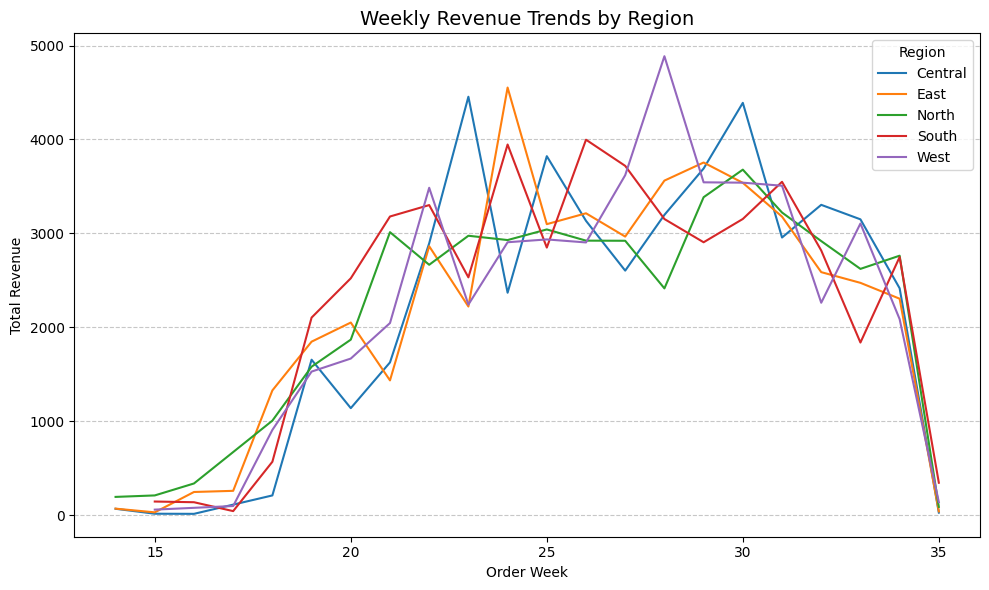

In [47]:
#visual exploration
#line plot - weekly revenue trends by region
plt.figure(figsize=(10, 6))

for region in weekly_revenue_region['region'].unique():
  region_data = weekly_revenue_region[weekly_revenue_region['region'] == region]
  plt.plot(region_data['order_week'], region_data['revenue'], label=region, linewidth=1.5)

plt.xlabel('Order Week')
plt.ylabel('Total Revenue')
plt.title('Weekly Revenue Trends by Region', fontsize=14)
plt.legend(title='Region')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

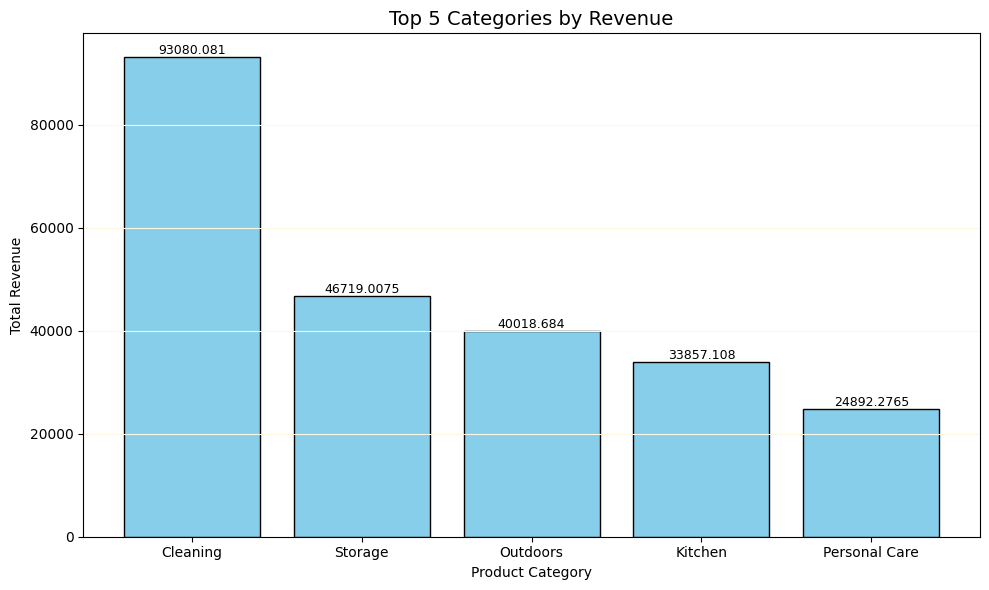

In [48]:
#bar chart - top 5 categories by revenue
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(category_perform['category'],
              category_perform['total_revenue'],
              color='skyblue',
              edgecolor='black')

ax.set_xlabel('Product Category')
ax.set_ylabel('Total Revenue')
ax.set_title('Top 5 Categories by Revenue', fontsize=14)

ax.grid(True, axis='y', color='#fdf6e3')

for bar in bars:
  height = bar.get_height()
  ax.text(bar.get_x() + bar.get_width() / 2, height + 1, f'{height}',
          ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

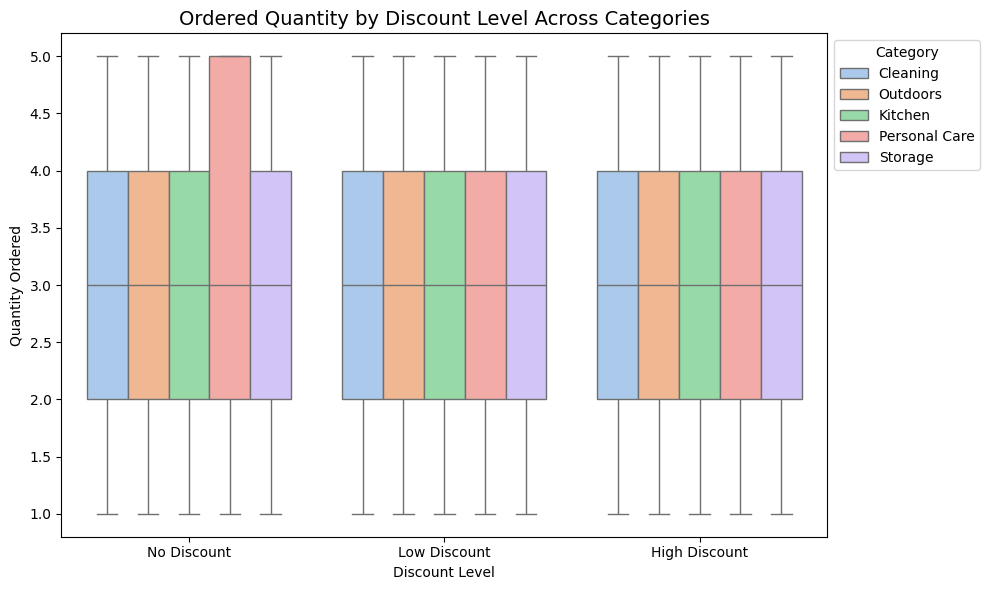

In [49]:
#boxplot - quantity vs discount across categories
merged_df['discount_level'] = pd.cut(
    merged_df['discount_applied'],
    bins = [-0.01, 0, 0.1, 0.2],
    labels = ['No Discount', 'Low Discount', 'High Discount']
)

plt.figure(figsize=(10, 6))

sns.boxplot(data=merged_df,
            x='discount_level',
            y='quantity',
            hue='category',
            palette='pastel')

plt.xlabel('Discount Level')
plt.ylabel('Quantity Ordered')
plt.title('Ordered Quantity by Discount Level Across Categories', fontsize=14)
plt.legend(title='Category', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

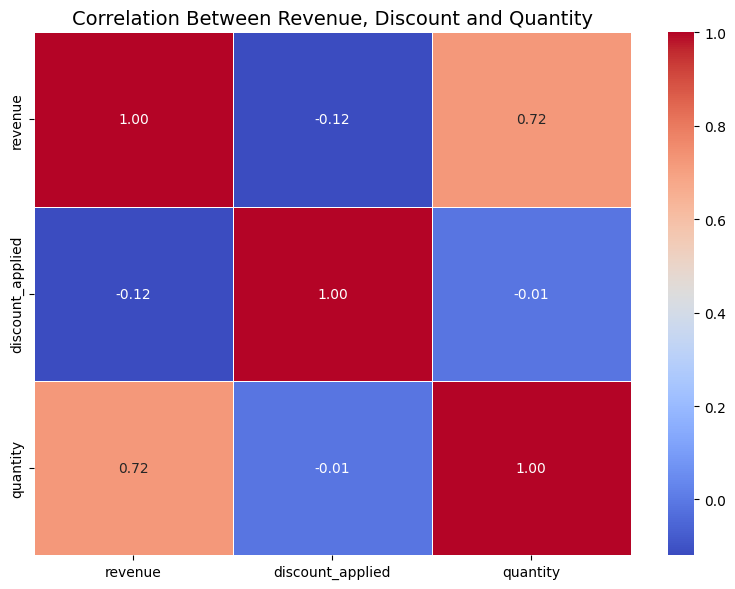

In [50]:
#heatmap - correlation between revenue, discount, and quantity - correlation matrix
corr_matrix = merged_df[['revenue', 'discount_applied', 'quantity']].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Between Revenue, Discount and Quantity', fontsize=14)
plt.tight_layout()
plt.show()

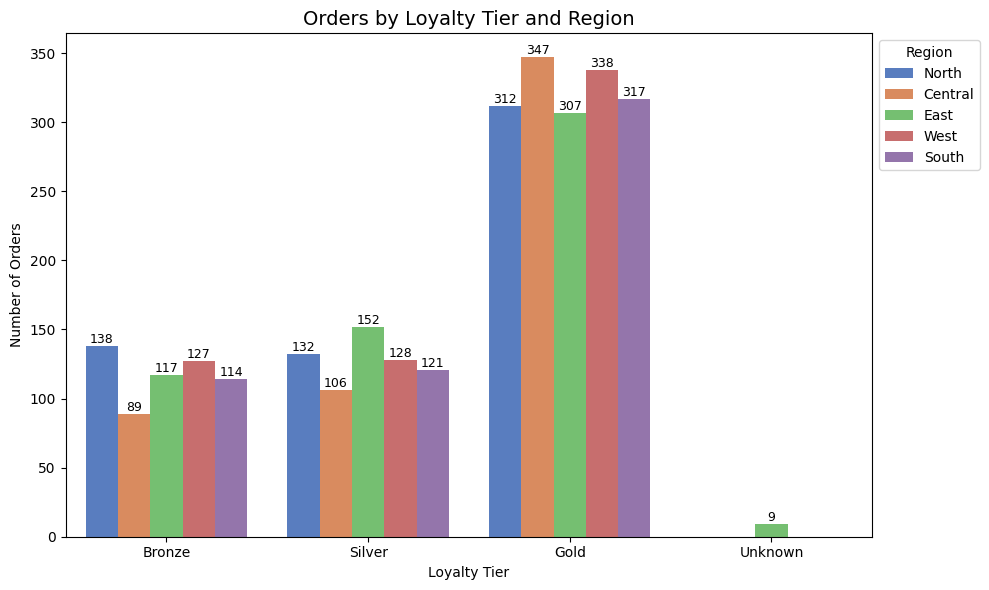

In [51]:
#countplot - orders by loyalty tier (with hue = region)
plt.figure(figsize=(10, 6))

sns.countplot(data=merged_df,
              x='loyalty_tier',
              hue='region_y',
              order=['Bronze', 'Silver', 'Gold', 'Unknown'],
              palette='muted')

plt.xlabel('Loyalty Tier')
plt.ylabel('Number of Orders')
plt.title('Orders by Loyalty Tier and Region', fontsize=14)

ax = plt.gca()
for container in ax.containers:
  ax.bar_label(container, fontsize=9)

plt.legend(title='Region', bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()

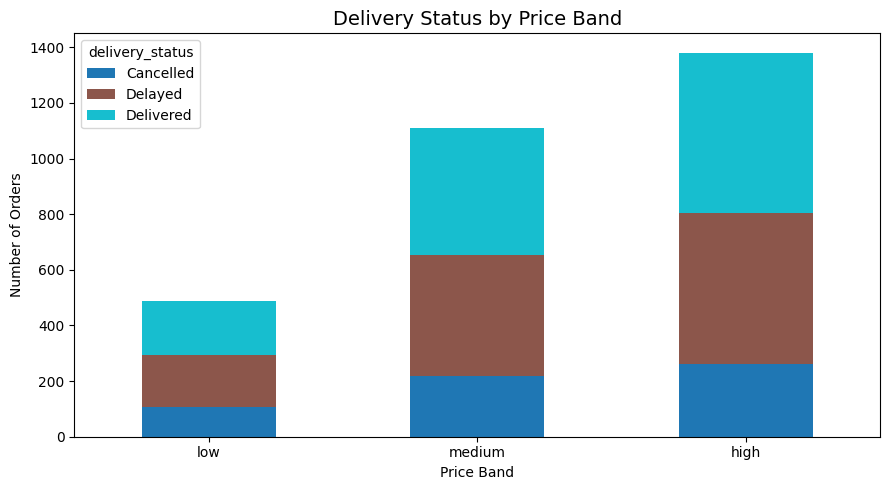

In [52]:
#stacked bar - delivery status by price band
#inconsistencies in delivery status label during aggregation and corrected it for grouping
delivery_by_price = (
    merged_df
    .groupby(['price_band', 'delivery_status'], observed=True)
    .size()
    .unstack(fill_value=0))
#low = cheap, medium = mid-range, high=expensive - price band

delivery_by_price.plot(kind='bar',
                       stacked=True,
                       figsize=(9, 5),
                       colormap='tab10')
plt.xlabel('Price Band')
plt.xticks(rotation=0)
plt.ylabel('Number of Orders')
plt.title('Delivery Status by Price Band', fontsize=14)
plt.tight_layout()
plt.show()

##Stretch Tasks (Optional Analysis)

Additional analysis was completed to demonstrate advanced techniques, including:
- Query-based filtering of customer behaviour
- Revenue normalisation using MinMaxScaler
- Identification of potentially underperforming products based on sales volume, discounting, and delivery delays

These tasks extend the core analysis but are not required for the main report findings.

In [55]:
#stretch tasks
#use .query() to extract:
  #customers who signed up in Q2 (April, May, June)
  #placed an order within 14 days
  #received a discount > 20%

q2_customers = merged_df.query(
    "signup_date.dt.month in [4,5,6]"
)

q2_order_discount = merged_df.query(
    "signup_date.dt.month in [4,5,6] and days_to_order <= 14 and discount_applied >= 0.20"
)

q2_order_discount.head()

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region_x,discount_applied,...,region_y,loyalty_tier,revenue,order_week,price_band,days_to_order,email_domain,is_late,signup_month,discount_level
155,O544736,C00369,P0013,5.0,21.96,2025-06-17,Delivered,Credit Card,Central,0.2,...,West,Bronze,87.840,25,medium,0,yahoo.com,False,2025-06,High Discount
832,O894163,C00360,P0004,2.0,9.28,2025-04-16,Cancelled,Credit Card,Central,0.2,...,East,Silver,14.848,16,low,-3,crane-washington.com,False,2025-05,High Discount


In [56]:
#use MinMaxScaler to normalise revenue or price
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

merged_df['revenue_scaled'] = scaler.fit_transform(merged_df[['revenue']])

merged_df[['revenue', 'revenue_scaled']].head()

,revenue,revenue_scaled
0,117.750,0.457431
1,94.600,0.361987
2,25.228,0.075976
3,26.208,0.080016
4,38.096,0.129029


In [61]:
#flag underperforming products (low quantity, high discount, delayed deliveries)
product_performance = (
    merged_df
    .groupby(['product_id', 'product_name', 'category'])
    .agg(
        total_quantity=('quantity', 'sum'),
        average_discount=('discount_applied', 'mean'),
        delayed_delivery=('is_late', 'mean')
    )
    .reset_index()
)

underperforming_products = product_performance.query(
    "total_quantity < 100 and average_discount > 0.15 and delayed_delivery > 0.30"
)

underperforming_products.head()

,product_id,product_name,category,total_quantity,average_discount,delayed_delivery
